## Sistema de agentes musicales con LangGraph + SunnoAPI

El objetivo del siguiente proyecto es crear un sistema de agentes capaz de resolver las consultas del usuario mediante un flujo de agentes que le permita realizar tareas en función de la consulta realizada.

**Instalación de dependencias:**
```
pip install -U langgraph langchain-cohere langchain-core pydantic python-dotenv gradio ipython pillow jupyter ipywidgets

pip install -r requirements.txt
```

**Cada vez que se instale un nuevo paquete:**

```
pip freeze > requirements.txt
```

### Importaciones de paquetes iniciales:

Este es un ejemplo de las dependencias que necesitamos importar para el proyecto, pero todavía falta aclarar todos los paquetes que necesitaremos instalar por lo tanto esto sólo sirve de prueba por el momento.

In [27]:
import os
import time
import requests
from typing import Annotated, List, Dict, Optional, TypedDict, Any
from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.tools import tool
from langchain_core.documents import Document

from langchain_cohere import ChatCohere, CohereEmbeddings
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_community.vectorstores import FAISS

from pydantic import BaseModel, Field
from IPython.display import Image, display

import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders
from fpdf import FPDF




In [28]:
#Cargamos las variables de entorno desde el archivo .env
load_dotenv(override=True)

True

### Creamos las tools + Agentes

Esto es una prueba y está sujeto a cambio lo más probable es que acabemos utilizando StructuredTool para esto.

Test de creación de tool + agente:

In [29]:
# --- 1. DEFINICIÓN DEL ESTADO UNIFICADO ---
class State(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    concerts: List[Dict[str, Any]]
    suno_audio_url: str
    formato_entrega: str
    pdf_path: str
    user_email: Optional[str]
    mp3_path: Optional[str]
    # --- Flags de Enrutamiento ---
    needs_research: bool # Si True, pasa por Investigador
    needs_music: bool    # Si True, pasa por Músico
    needs_export: bool   # Si True, pasa por Editor


### Agente Investigador

In [30]:
# ------------------------------------------------------------
# RAG - BASE VECTORIAL FAISS
# ------------------------------------------------------------

FAISS_PATH = "faiss_memory"
embeddings = CohereEmbeddings(model="embed-english-v3.0")

if os.path.exists(FAISS_PATH):
    vectorstore = FAISS.load_local(
        FAISS_PATH,
        embeddings,
        allow_dangerous_deserialization=True
    )
else:
    vectorstore = FAISS.from_documents([], embeddings)

In [31]:
serper = GoogleSerperAPIWrapper(serper_api_key=os.getenv("SERPER_API_KEY"))

In [32]:
# ------------------------------------------------------------
# TOOLS DEL INVESTIGADOR
# ------------------------------------------------------------

@tool
def retrieve_events_from_memory(query: str) -> List[Dict[str, Any]]:
    """Recupera conciertos desde la memoria vectorial."""
    docs = vectorstore.similarity_search(query, k=5)
    return [d.metadata for d in docs]


@tool
def search_events_tool(artist: str) -> List[Dict[str, Any]]:
    """Busca conciertos y festivales en la web."""
    query = f"upcoming concerts and festivals {artist} Europe"
    results = serper.run(query)

    concerts = []
    for r in results.split("\n"):
        if r.strip():
            concerts.append({
                "id": hash(r),
                "artist": artist,
                "raw_text": r,
                "city": None,
                "country": None,
                "date": None,
                "price": None,
                "type": "concert",
                "link": None
            })
    return concerts


@tool
def store_events_in_memory(concerts: List[Dict[str, Any]]) -> str:
    """Guarda conciertos en FAISS."""
    docs = []
    for c in concerts:
        text = f"{c.get('artist')} {c.get('city')} {c.get('country')} {c.get('date')}"
        docs.append(Document(page_content=text, metadata=c))

    if docs:
        vectorstore.add_documents(docs)
        vectorstore.save_local(FAISS_PATH)

    return "Eventos almacenados en memoria"



In [33]:
# ------------------------------------------------------------
# NORMALIZACIÓN
# ------------------------------------------------------------

def normalize_concerts(concerts: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    unique = {c["id"]: c for c in concerts}.values()
    result = []

    for c in unique:
        c["city"] = c.get("city") or "Por confirmar"
        c["country"] = c.get("country") or "Por confirmar"
        c["price"] = c.get("price") or "Por confirmar"
        result.append(c)

    return result


In [34]:
# ------------------------------------------------------------
# AGENTE INVESTIGADOR
# ------------------------------------------------------------

def investigator_node(state: State) -> State:
    system_prompt = (
        "Eres un INVESTIGADOR DE EVENTOS MUSICALES.\n"
        "Usas RAG con memoria vectorial.\n"
        "Primero recupera eventos existentes.\n"
        "Si no hay datos, busca fuera.\n"
        "Devuelve siempre datos estructurados."
    )

    llm = ChatCohere(
        model="command-a-03-2025",
        temperature=0,
        preamble=system_prompt
    )

    llm_with_tools = llm.bind_tools([
        retrieve_events_from_memory,
        search_events_tool,
        store_events_in_memory
    ])

    response = llm_with_tools.invoke(state["messages"])

    return {**state, "messages": [response]}


def investigator_merge_node(state: State) -> State:
    last_msg = state["messages"][-1]
    concerts = state.get("concerts", [])

    if isinstance(last_msg.content, list):
        concerts = normalize_concerts(last_msg.content)
        store_events_in_memory.invoke({"concerts": concerts})

    return {**state, "concerts": concerts}


def route_after_investigator(state: State):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "investigator_tools"
    return "musician"



### Agente Músico

In [35]:
# Cargamos la clave de la API de Suno desde las variables de entorno para configurar la cabecera de las solicitudes HTTP

SUNO_API_KEY=os.getenv("SUNO_API_KEY")
SUNO_CALLBACK_URL = "https://api.example.com/callback" 
SUNO_BASE_URL="https://api.sunoapi.org/api/v1"
HEADERS = {
    "Authorization": f"Bearer {SUNO_API_KEY}",
    "Content-Type": "application/json"
}

### Esquema de datos

Definimos un esquema de datos con Pydantic que se ajuste al payload que requiere Suno para hacer peticiones a su API

In [36]:
# Esquema de datos 

class MusicCustomSchema(BaseModel):
    prompt: str = Field(description="Letras de la canción o descripción detallada del contenido.")
    style: str = Field(description="Géneron musical o estilo (ej: Classical, Rock, Synthwave).")
    title: str = Field(default="Untitled", description="Título de la canción.")
    instrumental: bool = Field(default=False, description="Si es True, genera solo música sin voz.")
    negativeTags: Optional[str] = Field(default=None, description="Estilos o elementos a evitar.")
    vocalGender: Optional[str] = Field(default=None, description="Género de la voz: 'm' (masculino) o 'f' (femenino).")
    weirdnessConstraint: float = Field(default=0.0, description="Nivel de rareza experimental (0.0 a 1.0).")

### Función auxiliar

Esta función nos permite hacer peticiones GET después de ejecutar la tool de generación de audio para extraer los datos de la canción (en este caso la url)

In [37]:
def _poll_for_audio(task_id: str, max_attempts=30) -> str:
    """Consulta el estado mapeando correctamente sunoData."""
    info_url = f"{SUNO_BASE_URL}/generate/record-info?taskId={task_id}"
    
    for i in range(max_attempts):
        time.sleep(10) 
        try:
            response = requests.get(info_url, headers=HEADERS, timeout=15)
            full_res = response.json()
            data = full_res.get('data', {})
            status = data.get('status')
            
            print(f"   [Polling] Intento {i+1}: Estado {status}")

            if status == 'SUCCESS':
                # Buscamos en 'sunoData' dentro de 'response'
                response_obj = data.get('response', {})
                songs = response_obj.get('sunoData', [])
                
                if songs and len(songs) > 0:
                    # Uso el sourceAudioUrl que es el enlace directo de Suno
                    audio_url = songs[0].get('sourceAudioUrl') or songs[0].get('audioUrl')
                    return f"ESTADO: OPERACIÓN EXITOSA. URL DE DESCARGA: {audio_url}"
                else:
                    return f"ERROR: SUCCESS pero sunoData está vacío. Respuesta: {full_res}"
            
            elif status == 'FAILED':
                return f"ERROR: Fallo en Suno. {data.get('errorMessage')}"
                
        except Exception as e:
            print(f"Error en polling: {e}")
            
    return "ERROR: Tiempo de espera agotado."

### Tools del Agente Musical

In [38]:
# Tool para generación personalizada de música con Suno
@tool(args_schema=MusicCustomSchema)
def suno_generate_custom(
    prompt: str, 
    style: str, 
    title: str = "Untitled", 
    instrumental: bool = False,
    negativeTags: Optional[str] = None,
    vocalGender: Optional[str] = None,
    weirdnessConstraint: float = 0.0
) -> str:
    """Genera música personalizada usando el modelo V4_5ALL de Suno."""
    url = f"{SUNO_BASE_URL}/generate"
    
    payload = {
        "customMode": True,
        "instrumental": instrumental,
        "model": "V4_5ALL",
        "callBackUrl": SUNO_CALLBACK_URL, 
        "prompt": prompt,
        "style": style,
        "title": title,
        "styleWeight": 0.65,
        "weirdnessConstraint": weirdnessConstraint,
        "audioWeight": 0.65
    }
    
    if negativeTags:
        payload["negativeTags"] = negativeTags

    if vocalGender:
        payload["vocalGender"] = vocalGender


    try:
        print(f"DEBUG: Enviando a {url}...")
        response = requests.post(url, json=payload, headers=HEADERS, timeout=30)
        res_json = response.json()
        
        # Validación de la respuesta
        if res_json.get('code') != 200:
            msg = res_json.get('msg', 'Error desconocido')
            print(f"❌ ERROR API ({res_json.get('code')}): {msg}")
            return f"Error de Suno: {msg}"

        # Si llegamos aquí, data ya no debería ser None
        data = res_json.get('data')
        task_id = data.get('taskId')
        
        print(f"✅ Tarea aceptada. ID: {task_id}. Iniciando polling...")
        return _poll_for_audio(task_id)

    except Exception as e:
        print(f"❌ ERROR CRÍTICO: {str(e)}")
        return f"Error al llamar a Suno: {str(e)}"
    
# Esta tool hay que testearla todavía
@tool
def suno_extend_audio(audio_id: str, prompt: str) -> str:
    """Extiende una canción existente dado su audio_id."""
    url = f"{SUNO_BASE_URL}/generate/continue"
    payload = {"audioId": audio_id, "prompt": prompt}
    try:
        response = requests.post(url, json=payload, headers=HEADERS)
        task_id = response.json().get('data', {}).get('taskId')
        return _poll_for_audio(task_id)
    except Exception as e:
        return f"Error al extender: {str(e)}"

In [39]:


# Nodo del Agente Musical
def musician_node(state: State):
    """
    Nodo Musician Unificado:
    Combina la ingeniería de prompts detallada con la configuración
    nativa de Cohere para garantizar la entrega de la URL.
    """

    # Instrucciones elaboradas (Preamble)
    preamble = (
        "Eres el experto en producción de audio y composición AI (nodo 'mus.'). "
        "Tu responsabilidad principal es transformar las peticiones creativas del usuario "
        "en parámetros técnicos precisos para la API de Suno utilizando el modelo 'V4_5ALL'.\n\n"
        
        "### TAREAS ESPECÍFICAS:\n"
        "1. TRADUCCIÓN DE ESTILO: Mapea descripciones sensoriales a etiquetas de género en el campo 'style' "
        "(ej: 'música para estudiar' -> 'lo-fi, chill, minimalist piano').\n"
        "2. CONTROL DE RAREZA: Si el usuario menciona términos como 'experimental', 'extraño', 'vanguardista' "
        "o 'nunca antes escuchado', incrementa el valor de 'weirdnessConstraint' (rango 0.0 a 1.0).\n"
        "3. FILTRADO NEGATIVO: Identifica elementos no deseados (ej: 'sin batería', 'no guitarras') y "
        "colócalos exclusivamente en el campo 'negativeTags' sin usar palabras de negación.\n"
        "4. IDENTIDAD VOCAL: Si detectas que el usuario prefiere una voz masculina o femenina, "
        "asigna 'm' o 'f' al campo 'vocalGender'. Si pide instrumental, activa 'instrumental=True'.\n\n"
        
        "### REGLAS DE OPERACIÓN CRÍTICAS:\n"
        "- Si la herramienta devuelve 'ESTADO: OPERACIÓN EXITOSA', extrae la URL y dásela al usuario.\n"
        "- NUNCA digas que hubo un error o que lo sientes si recibes una URL de descarga en el historial.\n"
        "- No inventes la URL. Debes esperar a que la herramienta confirme el estado 'SUCCESS' mediante el polling.\n"
        "- Tu respuesta final DEBE incluir la URL del audio y un breve resumen técnico de la producción realizada.\n"
        "- IMPORTANTE: Ignora los múltiples mensajes de estado intermedio (PENDING, TEXT_SUCCESS) del historial; "
        "céntrate únicamente en el mensaje final de la herramienta que contiene la URL."
    )

    # Configuración del LLM
    llm = ChatCohere(
        model="command-a-03-2025", 
        temperature=0,
        preamble=preamble
    )
    
    # Vinculación de herramientas
    llm_with_tools = llm.bind_tools([suno_generate_custom, suno_extend_audio])

    # Invocación pasando el historial completo del estado
    # Patch for Cohere constraint
    msgs = state["messages"]
    if msgs and msgs[-1].type == "ai":
        msgs = msgs + [HumanMessage(content="Proceed with music generation based on context.")]
    response = llm_with_tools.invoke(msgs)
    
    return {"messages": [response]}


In [40]:
# --- ROUTER NODE & EDGES ---
class RouteSchema(BaseModel):
    needs_research: bool = Field(description="True si busca info/conciertos.")
    needs_music: bool = Field(description="True si quiere generar música.")
    needs_export: bool = Field(description="True si quiere enviar email o pdf.")
    reasoning: str = Field(description="Explicación.")

def router_node(state: State):
    print("Canalizando petición... ")
    last_msg = state["messages"][-1].content
    system_prompt = (
        "Eres un Router inteligente. Tu trabajo es clasificar la intención del usuario y activar los flags correctos. "
        "NO actives flags que no sean estrictamente necesarios.\n\n"
        "FLAGS:\n"
        "- needs_research: True si el usuario pide buscar información, datos de conciertos, noticias, etc.\n"
        "- needs_music: True si el usuario pide crear canciones, letras, o música.\n"
        "- needs_export: True si el usuario pide explícitamente enviar un email, crear un PDF, o 'dáselo al editor'.\n\n"
        "CASOS DE USO:\n"
        "1. 'Busca conciertos de X y mándamelo por mail' -> needs_research=True, needs_export=True. (Music=False)\n"
        "2. 'Crea una canción de rock' -> needs_music=True. (Research=False, Export=False - a menos que pida enviarla)\n"
        "3. 'Investiga sobre X y con la info haz una canción y mándamela' -> Research=True, Music=True, Export=True.\n"
    )
    llm = ChatCohere(model="command-r-plus-08-2024", temperature=0, preamble=system_prompt)
    structured_llm = llm.with_structured_output(RouteSchema)
    try:
        routing = structured_llm.invoke(last_msg)
    except Exception as e:
        print(f"Error Router: {e}")
        routing = RouteSchema(needs_research=True, needs_music=True, needs_export=True, reasoning="Error")
    
    print(f"📍 Router decidió: {routing}")
    return {
        "needs_research": routing.needs_research,
        "needs_music": routing.needs_music,
        "needs_export": routing.needs_export
    }

def route_after_router(state: State):
    if state.get("needs_research"):
        return "investigator"
    elif state.get("needs_music"):
        return "musician"
    elif state.get("needs_export"):
        return "editor"
    else:
        return END

def route_after_investigator(state: State):
    # Check tool calls first
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "investigator_tools"
    # Flow logic
    if state.get("needs_music"):
        return "musician"
    elif state.get("needs_export"):
        return "editor"
    return END

def route_after_musician(state: State):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "musician_tools"
    if state.get("needs_export"):
        return "editor"
    return END

def route_after_editor(state: State):
    last_msg = state["messages"][-1]
    # Standard tool check for Editor if it uses tools
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "editor_tools"
    return END



### Test agente musical

In [41]:
# --- TEST EXTENDIDO: VARIOS ESCENARIOS ---
def run_scenarios():
    scenarios = [
        ("ESCENARIO 1: Solo Música", "Crea una canción de Jazz."),
        ("ESCENARIO 2: Solo Investigación", "Busca conciertos de Coldplay en 2024."),
        ("ESCENARIO 3: Completo (Inv+Mus+Ed)", "Busca conciertos de Taylor Swift, crea una canción sobre ella y mándame todo por email a test@test.com")
    ]
    
    for title, query in scenarios:
        print(f"\n{'='*60}\n{title}\nQuery: '{query}'\n{'='*60}")
        try:
            # Estado inicial limpio para cada prueba
            state = {
                "messages": [HumanMessage(content=query)],
                "concerts": [],
                "suno_audio_url": "",
                "formato_entrega": "local",
                "pdf_path": "",
                "user_email": "",
                "mp3_path": "",
                "needs_research": False,
                "needs_music": False,
                "needs_export": False
            }
            
            # Ejecutar Grafo
            for chunk in app_completa.stream(state, stream_mode="updates"):
                for node, values in chunk.items():
                    print(f"   📍 Paso por nodo: {node}")
                    if node == 'router':
                        print(f"      Flags: Research={values.get('needs_research')}, Music={values.get('needs_music')}, Export={values.get('needs_export')}")
        except Exception as e:
            print(f"Error en escenario: {e}")

# if __name__ == "__main__":
#     run_scenarios()


### Agente Editor

In [42]:
# --- IMPORTS FROM EDITOR NODE ---
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders
from fpdf import FPDF
from typing import TypedDict, List, Dict, Any, Optional
import os
from langchain_core.tools import tool

# --- STATE DEFINITION FOR EDITOR ---
class State(TypedDict):
    concerts: List[Dict[str, Any]]  # Lista de conciertos
    suno_audio_url: str             # URL del audio generado por Suno
    formato_entrega: str            # 'email' o 'local'
    pdf_path: str                   # Ruta donde se guardó el PDF
    user_email: Optional[str]       # Email del usuario (opcional si es local)
    mp3_path: Optional[str]         # Ruta del archivo MP3 (opcional)
    # Otros campos que puedan existir en el grafo global...
    messages: Annotated[list, add_messages]

### Tools


In [43]:
def generate_pdf(concerts: List[Dict[str, Any]], suno_audio_url: str) -> str:
    """\n
    Genera un PDF utilizanod un LLM (Cohere) para escribir el contenido.\n
    La instrucción es: hacer una lista de los conciertos de la banda con los precios y luego poner la url de suno.\n
    """
    try:
        # Inicializar LLM
        llm = ChatCohere(temperature=0.5)
        
        # Crear prompt
        prompt = (
            f"Tienes que hacer una lista de los conciertos de la banda con los precios basándote en estos datos: {concerts}. "
            f"Y luego poner la url de suno: {suno_audio_url}. "
            f"IMPORTANTE: NO uses tablas de Markdown (con barras verticales '|'). "
            f"El output se escribirá directamente en un PDF simple. "
            f"Usa un formato de lista limpio y legible, por ejemplo:\n"
            f"- Fecha: [Fecha] en [Ciudad] - Precio: [Precio]. ([Link])\n"
            f"O usa párrafos elegantes. Agrega un título o introducción breve si queda bien."
        )
        
        # Invocar LLM
        response = llm.invoke(prompt)
        content = response.content
        
    except Exception as e:
        print(f"Error al llamar al LLM: {e}")
        content = f"Error generando contenido. Datos: {concerts}, URL: {suno_audio_url}"

    # Generar PDF con FPDF
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)

    # Título Genérico
    pdf.set_font("Arial", style="B", size=16)
    pdf.cell(0, 10, txt="Información de la Banda", ln=True, align='C')
    pdf.ln(10)
    # Cuerpo del texto generado por LLM
    pdf.set_font("Arial", size=12)
    # FPDF básico puede fallar con caracteres unicode no soportados en latin-1.
    # Reemplazamos caracteres problemáticos para evitar 'UnicodeEncodeError'.
    safe_content = content.encode('latin-1', 'replace').decode('latin-1')
    pdf.multi_cell(0, 10, txt=safe_content)
    output_filename = "concierto_suno.pdf"
    pdf.output(output_filename)
    return os.path.abspath(output_filename)

from langchain_core.tools import tool

@tool
def generate_pdf_tool(concerts: List[Dict[str, Any]], suno_audio_url: str) -> str:
    """Genera el PDF con conciertos y link de audio usando LLM."""
    return generate_pdf(concerts, suno_audio_url)


@tool
def send_email_tool(pdf_path: str, receiver_email: str, mp3_path: Optional[str] = None):
    """Envía el PDF generado y opcionalmente un MP3 por correo electrónico."""
    sender_email = os.getenv("EMAIL_SENDER")
    sender_password = os.getenv("EMAIL_PASSWORD")
    
    if not sender_email or not sender_password:
        print("Advertencia: No se han configurado EMAIL_SENDER o EMAIL_PASSWORD. No se envió el correo.")
        return "Error: Credenciales faltantes"

    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = receiver_email
    msg['Subject'] = "Tu Resumen de Conciertos y Música"

    body = "Adjunto encontrarás el PDF con la información de los conciertos y tu canción de Suno."
    msg.attach(MIMEText(body, 'plain'))

    # Adjuntar PDF
    try:
        filename = os.path.basename(pdf_path)
        with open(pdf_path, "rb") as attachment:
            part = MIMEBase("application", "octet-stream")
            part.set_payload(attachment.read())
        
        encoders.encode_base64(part)
        part.add_header(
            "Content-Disposition",
            f"attachment; filename= {filename}",
        )
        msg.attach(part)

        # Adjuntar MP3 si existe
        if mp3_path and os.path.exists(mp3_path):
            try:
                mp3_filename = os.path.basename(mp3_path)
                with open(mp3_path, "rb") as attachment:
                    part = MIMEBase("audio", "mpeg")
                    part.set_payload(attachment.read())
                
                encoders.encode_base64(part)
                part.add_header(
                    "Content-Disposition",
                    f"attachment; filename= {mp3_filename}",
                )
                msg.attach(part)
            except Exception as e:
                print(f"Error adjuntando MP3: {e}")

        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls()
        server.login(sender_email, sender_password)
        server.send_message(msg)
        server.quit()
        return "Correo enviado con éxito"
    except Exception as e:
        print(f"Error enviando correo: {e}")
        return f"Error enviando correo: {e}"

### Nodo Editor

In [44]:
# --- NODO AGENTE EDITOR ---
def editor_agent_node(state: State):
    """
    Nodo Agente Editor: Decide cuándo generar el PDF y enviarlo basándose en el estado.
    """
    concerts = state.get("concerts", [])
    suno_url = state.get("suno_audio_url", "")
    email = state.get("user_email", "")
    
    # Contexto para que el LLM sepa qué datos tiene
    context_str = (
        f"Datos disponibles:\n"
        f"- Conciertos: {concerts}\n"
        f"- URL Suno: {suno_url}\n"
        f"- Email usuario: {email}\n"
    )

    preamble = (
        "Eres el Agente Editor. Tu trabajo es recopilar la información final y generar los entregables.\n"
        "Tienes acceso a herramientas para generar PDF ('generate_pdf_tool') y enviar emails ('send_email_tool').\n"
        "REGLAS:\n"
        "1. SI tienes datos de conciertos y URL de suno, DEBES generar el PDF.\n"
        "2. DESPUÉS de generar el PDF, SI tienes un email de usuario, DEBES enviarlo por correo.\n"
        "3. Si ya generaste el PDF y (enviaste el correo o no hay email), termina con un mensaje final.\n"
        f"CONTEXTO ACTUAL: {context_str}"
    )

    # Usamos el mismo modelo que el músico o uno robusto
    llm = ChatCohere(
        model="command-r-plus-08-2024", # O el disponible
        temperature=0.1,
        preamble=preamble
    )
    
    tools = [generate_pdf_tool, send_email_tool]
    llm_with_tools = llm.bind_tools(tools)
    
    # Invocamos al modelo
    # Patch for Cohere constraint
    msgs = state["messages"]
    if msgs and msgs[-1].type == "ai":
        msgs = msgs + [HumanMessage(content="Proceed with editing/exporting based on context.")]
    response = llm_with_tools.invoke(msgs)
    
    return {"messages": [response]}



### Visualizar grafo

In [45]:
# --- CONSTRUCCIÓN DEL GRAFO FINAL ---
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(State)

# 1. Router
workflow.add_node("router", router_node)

# 2. Investigador
workflow.add_node("investigator", investigator_node)
workflow.add_node("investigator_tools", ToolNode([
    retrieve_events_from_memory, search_events_tool, store_events_in_memory
]))
# workflow.add_node("investigator_merge", investigator_merge_node) 
# NOTA: Simplificamos el merge inyectándolo en el nodo investigador o asumiendo que el estado se actualiza en el tool
# Pero para mantener la estructura original si es necesaria:
workflow.add_node("investigator_merge", investigator_merge_node)

# 3. Músico
workflow.add_node("musician", musician_node)
workflow.add_node("musician_tools", ToolNode([suno_generate_custom, suno_extend_audio]))

# 4. Editor
workflow.add_node("editor", editor_agent_node)
workflow.add_node("editor_tools", ToolNode([generate_pdf_tool, send_email_tool]))

# --- EDGES Y ENRUTAMIENTO ---

# Entry Point -> Router
workflow.set_entry_point("router")

# Router Logic
workflow.add_conditional_edges(
    "router",
    route_after_router,
    {
        "investigator": "investigator",
        "musician": "musician",
        "editor": "editor",
        END: END
    }
)

# Investigador Logic
workflow.add_conditional_edges(
    "investigator",
    route_after_investigator,
    {
        "investigator_tools": "investigator_tools",
        "musician": "musician",
        "editor": "editor",
        END: END
    }
)
# Retorno de herramientas investigador
workflow.add_edge("investigator_tools", "investigator_merge")
workflow.add_edge("investigator_merge", "investigator") 

# Músico Logic
workflow.add_conditional_edges(
    "musician",
    route_after_musician,
    {
        "musician_tools": "musician_tools",
        "editor": "editor",
        END: END
    }
)
workflow.add_edge("musician_tools", "musician")

# Editor Logic
workflow.add_conditional_edges(
    "editor",
    route_after_editor,
    {
        "editor_tools": "editor_tools",
        END: END
    }
)
workflow.add_edge("editor_tools", "editor")

app_completa = workflow.compile()
print("Grafo Final Dinámico compilado con éxito.")



Grafo Final Dinámico compilado con éxito.


Generando diagrama del grafo...


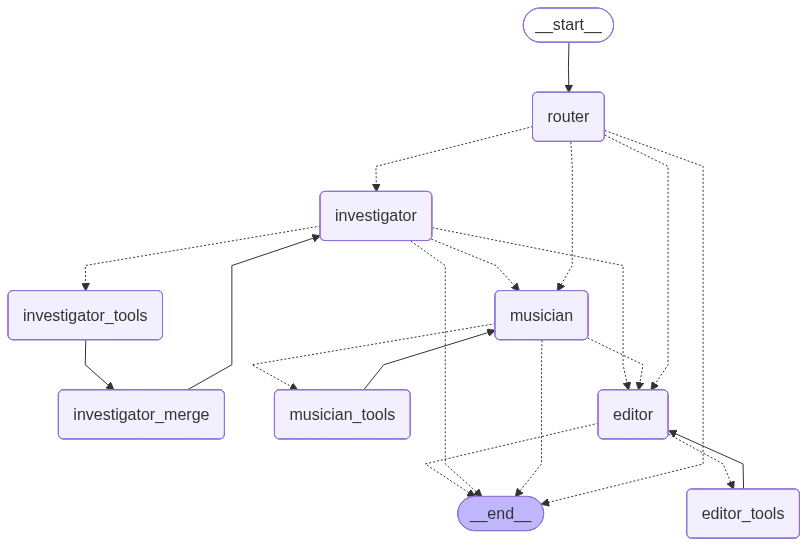

In [21]:
# --- VISUALIZACIÓN DEL GRAFO ---
try:
    from IPython.display import Image, display
    print("Generando diagrama del grafo...")
    display(Image(app_completa.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"No se pudo visualizar el grafo: {e}")


In [46]:
# --- VERIFICACIÓN FINAL ---
if __name__ == "__main__":
    try:
        run_scenarios()
    except Exception as e:
        print(f"Error running scenarios: {e}")



ESCENARIO 1: Solo Música
Query: 'Crea una canción de Jazz.'
Canalizando petición... 
📍 Router decidió: needs_research=False needs_music=True needs_export=False reasoning="El usuario ha pedido crear una canción de jazz, por lo que se activa el flag 'needs_music'."
   📍 Paso por nodo: router
      Flags: Research=False, Music=True, Export=False
   📍 Paso por nodo: musician
DEBUG: Enviando a https://api.sunoapi.org/api/v1/generate...
❌ ERROR API (401): You do not have access permissions
   📍 Paso por nodo: musician_tools
   📍 Paso por nodo: musician

ESCENARIO 2: Solo Investigación
Query: 'Busca conciertos de Coldplay en 2024.'
Canalizando petición... 
📍 Router decidió: needs_research=True needs_music=False needs_export=False reasoning='El usuario ha pedido buscar información sobre conciertos de Coldplay en 2024.'
   📍 Paso por nodo: router
      Flags: Research=True, Music=False, Export=False
   📍 Paso por nodo: investigator
   📍 Paso por nodo: investigator_tools
   📍 Paso por nodo: inv

In [ ]:
# --- INTERFAZ GRADIO ---
import gradio as gr

def chat_interface(message, history):
    try:
        # Estado inicial para cada interacción
        initial_state = {
            "messages": [HumanMessage(content=message)],
            "concerts": [],
            "suno_audio_url": "",
            "formato_entrega": "local",
            "pdf_path": "",
            "user_email": "",
            "mp3_path": "",
            "needs_research": False,
            "needs_music": False,
            "needs_export": False
        }
        
        print(f"\nUsuario: {message}")
        final_state = app_completa.invoke(initial_state)
        
        # Extraer respuesta
        last_msg = final_state["messages"][-1]
        response_text = last_msg.content
        
        # Añadir info extra si hay
        if final_state.get("suno_audio_url"):
            response_text += f"\n\n🎵 Audio generado: {final_state['suno_audio_url']}"
        if final_state.get("pdf_path"):
            response_text += f"\n\n📄 PDF generado en: {final_state['pdf_path']}"
            
        return response_text
    except Exception as e:
        return f"Error procesando solicitud: {str(e)}"

# Crear interfaz
demo = gr.ChatInterface(
    fn=chat_interface,
    title="Agente Musical AI ",
    description="Pide conciertos, crea canciones o exporta info.",
    examples=[
        "Busca conciertos de Taylor Swift",
        "Crea una canción de Jazz sobre programación",
        "Investiga sobre Coldplay y crea una canción triste"
    ]
)

if __name__ == "__main__":
    # launch(share=True) para link público
    demo.launch(share=True)


* Running on local URL:  http://127.0.0.1:7864
* Running on public URL: https://8e593bc3d6b6ac3c97.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



Usuario: Busca conciertos de Taylor Swift
Canalizando petición... 
📍 Router decidió: needs_research=True needs_music=False needs_export=False reasoning='La solicitud requiere investigación para encontrar información sobre conciertos de Taylor Swift.'
